In [ ]:
%pip install -q datasets

import os, math, random, time
from dataclasses import dataclass
from typing import List, Tuple, Dict

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset

import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision import models
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ==============================================================================
# 0. ВОСПРОИЗВОДИМОСТЬ
# ==============================================================================

def set_seed(seed: int = 42) -> None:
    """Фиксируем Python/NumPy/PyTorch seed."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

Device: cpu


In [ ]:
# ==============================================================================
# 1. ДАННЫЕ - mini-15
# ==============================================================================

food101 = load_dataset("food101")
food101_small_train = food101["train"]
food101_small_val   = food101["validation"]

CHOSEN_CLS = [9, 10, 17, 22, 28, 35, 39, 40, 53, 61, 70, 72, 75, 78, 99]

def filter_by_cls(ds, chosen):
    chosen_set = set(chosen)
    return ds.filter(lambda ex: ex["label"] in chosen_set)

food101_small_train = filter_by_cls(food101["train"],      CHOSEN_CLS)
food101_small_val   = filter_by_cls(food101["validation"], CHOSEN_CLS)

LABEL2NEW = {old: new for new, old in enumerate(sorted(CHOSEN_CLS))}
class_names = [food101["train"].features["label"].int2str(c) for c in sorted(CHOSEN_CLS)]
class_names_small = class_names

print("Классы:", class_names_small)
print(f"Train: {len(food101_small_train)}  Val: {len(food101_small_val)}")

Классы: ['breakfast_burrito', 'bruschetta', 'cheese_plate', 'chocolate_mousse', 'croque_madame', 'escargots', 'foie_gras', 'french_fries', 'hamburger', 'lobster_roll_sandwich', 'pad_thai', 'pancakes', 'pho', 'poutine', 'tuna_tartare']
Train: 11250  Val: 3750


In [ ]:
# ==============================================================================
# 2. ТРАНСФОРМАЦИИ
# ==============================================================================

IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

baseline_tf = T.Compose([
    T.Resize(256, interpolation=InterpolationMode.BILINEAR),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

strong_train_tf = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random"),
])

eval_tf = baseline_tf

In [ ]:
# ==============================================================================
# 3. DATASET / DATALOADER
# ==============================================================================

class HFDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform, label_map):
        self.data      = hf_split
        self.tf        = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex   = self.data[int(idx)]
        x    = self.tf(ex["image"])
        yold = int(ex["label"])
        y    = self.label_map[yold]
        return x, y

BATCH_SIZE = 64
NUM_CLASSES = 15

train_ds_base = HFDataset(food101_small_train, baseline_tf,    LABEL2NEW)
train_ds_aug  = HFDataset(food101_small_train, strong_train_tf, LABEL2NEW)
val_ds        = HFDataset(food101_small_val,   eval_tf,         LABEL2NEW)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoader | train: {len(train_ds_base)}  val: {len(val_ds)}  batch: {BATCH_SIZE}")

DataLoader | train: 11250  val: 3750  batch: 64


In [ ]:
# ==============================================================================
# 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ==============================================================================

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(1)
    return (preds == targets).float().mean().item()

@torch.no_grad()
def evaluate(model, dataloader):
    """Accuracy + Macro-F1 на сплите"""
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return acc, f1

def expected_calibration_error(ytrue, prob, nbins=15):
    """ECE"""
    p     = prob.max(axis=1)
    ypred = prob.argmax(axis=1)
    correct = (ypred == ytrue.astype(int))
    bins = np.linspace(0, 1, nbins + 1)
    ece  = 0.0
    for i in range(nbins):
        lo, hi = bins[i], bins[i + 1]
        mask = (p >= lo) & (p < hi) if i < nbins - 1 else (p >= lo) & (p <= hi)
        if mask.sum() == 0:
            continue
        conf_bin = p[mask].mean()
        acc_bin  = correct[mask].mean()
        ece     += mask.mean() * abs(acc_bin - conf_bin)
    return ece

@torch.no_grad()
def collect_preds_probs(model, loader):
    """Собираем логиты, метки и вероятности для ECE/Reliability-diagram."""
    model.eval()
    ys, ps, pr = [], [], []
    for xb, yb in tqdm(loader, desc="Collect", leave=False):
        xb, yb   = xb.to(device), yb.to(device)
        logits   = model(xb)
        probs    = torch.softmax(logits, dim=1)
        pr.append(probs.cpu().numpy())
        ps.append(logits.argmax(1).cpu().numpy())
        ys.append(yb.cpu().numpy())
    y    = np.concatenate(ys)
    p    = np.concatenate(ps)
    prob = np.concatenate(pr, axis=0)
    return y, p, prob

def reliability_points(ytrue, prob, nbins=10):
    p     = prob.max(axis=1)
    ypred = prob.argmax(axis=1)
    correct = (ypred == ytrue.astype(int))
    bins = np.linspace(0, 1, nbins + 1)
    xs, ys_r = [], []
    for i in range(nbins):
        lo, hi = bins[i], bins[i + 1]
        mask = (p >= lo) & (p < hi) if i < nbins - 1 else (p >= lo) & (p <= hi)
        if mask.sum() == 0:
            continue
        xs.append(p[mask].mean())
        ys_r.append(correct[mask].mean())
    return np.array(xs), np.array(ys_r)

In [ ]:
# ==============================================================================
# 5. ФУНКЦИИ ПОСТРОЕНИЯ МОДЕЛЕЙ
# ==============================================================================

def build_baseline_model(num_classes: int = NUM_CLASSES):
    """
    Baseline: ResNet-18, backbone заморожен, только FC обучается.
    """
    m = models.resnet18(pretrained=True)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)


def build_model_dropout(num_classes: int = NUM_CLASSES, p_drop: float = 0.3):
    """
    Улучшение 1 - Dropout(p=0.3) перед классификатором.
    Снижает переобучение, «выключая» случайные нейроны.
    """
    m = models.resnet18(pretrained=True)
    for p in m.parameters():
        p.requires_grad = False
    in_features = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=p_drop),
        nn.Linear(in_features, num_classes),
    )
    return m.to(device)

In [ ]:
# Метод 2 использует baseline-архитектуру, но меняет optimizer+criterion
# Метод 3 использует build_model_dropout + strong augmentations + AdamW + label_smoothing

# ==============================================================================
# 6. УНИВЕРСАЛЬНЫЙ ЦИКЛ ОБУЧЕНИЯ
# ==============================================================================

def train_model(
    model,
    train_loader,
    val_loader,
    epochs: int = 10,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    label_smoothing: float = 0.0,
    use_adamw: bool = False,
    checkpoint_path: str = "best_model.pt",
    mixup_cutmix: bool = False,
):
    """
    Единый train-loop для всех экспериментов.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    trainable = [p for p in model.parameters() if p.requires_grad]
    if use_adamw:
        optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable, lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    patience, no_improve = 3, 0

    for epoch in range(1, epochs + 1):
        model.train()
        tl, ta, n = 0.0, 0.0, 0
        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} train", leave=False):
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if mixup_cutmix:
                xb_mix, ya, yb2, lam, mode, used = apply_mixup_cutmix(xb, yb)
                logits = model(xb_mix)
                if used:
                    loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb2)
                else:
                    loss = criterion(logits, yb)
            else:
                logits = model(xb)
                loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            bs = yb.size(0)
            n  += bs
            tl += loss.item() * bs
            ta += accuracy_from_logits(logits, yb) * bs

        tl /= n; ta /= n

        model.eval()
        vl, va, n = 0.0, 0.0, 0
        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} val", leave=False):
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logits = model(xb)
                loss   = nn.CrossEntropyLoss()(logits, yb)    # val-loss без smoothing
                bs     = yb.size(0)
                n     += bs
                vl    += loss.item() * bs
                va    += accuracy_from_logits(logits, yb) * bs
        vl /= n; va /= n

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        print(f"Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
              f"train_acc={ta*100:.1f}  val_acc={va*100:.1f}")

        # Сохраняем лучшую модель по val_acc
        if va > best_val_acc:
            best_val_acc = va
            no_improve   = 0
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "val_acc": va}, checkpoint_path)
            print(f"  ✓ Saved best → {checkpoint_path}  val_acc={va*100:.2f}%")
        else:
            no_improve += 1

        if no_improve >= patience:
            print("Early stopping.")
            break

    return history

In [32]:
# ==============================================================================
# 7. MixUp / CutMix
# ==============================================================================

def rand_bbox(W, H, lam):
    cut_rat = (1 - lam) ** 0.5
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2


def apply_mixup_cutmix(x, y, alpha=0.4, p_mix=0.7):
    if random.random() > p_mix or alpha <= 0:
        return x, y, y, 1.0, "none", False
    lam     = np.random.beta(alpha, alpha)
    indices = torch.randperm(x.size(0), device=x.device)
    yb      = y[indices]
    mode    = "mixup" if random.random() < 0.5 else "cutmix"
    if mode == "mixup":
        x  = lam * x + (1 - lam) * x[indices]
        ya = y
    else:
        B, C, H, W = x.size()
        x1, y1, x2, y2 = rand_bbox(W, H, lam)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[indices, :, y1:y2, x1:x2]
        lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
        ya  = y
    return x, ya, yb, lam, mode, True

In [ ]:
# ==============================================================================
# ШАГ 1. BASELINE
# ==============================================================================

print("\n" + "="*60)
print("BASELINE: ResNet-18, frozen backbone, Adam lr=1e-3, no reg")
print("="*60)

set_seed(42)
model_base = build_baseline_model(NUM_CLASSES)

history_base = train_model(
    model_base,
    train_loader_base,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=0.0,
    label_smoothing=0.0,
    use_adamw=False,
    checkpoint_path="best_model.pt",
    mixup_cutmix=False,
)

ckpt = torch.load("best_model.pt", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.eval()

val_acc_base,  val_f1_base  = evaluate(model_base, val_loader)
y_base, p_base, prob_base   = collect_preds_probs(model_base, val_loader)
ece_base                    = expected_calibration_error(y_base, prob_base)

print(f"\nBASELINE  |  Val Acc={val_acc_base*100:.2f}%  F1-macro={val_f1_base:.4f}  ECE={ece_base:.4f}")


BASELINE: ResNet-18, frozen backbone, Adam lr=1e-3, no reg


Epoch 01/10  train_loss=1.7060  val_loss=1.0760  train_acc=51.6  val_acc=71.6
  ✓ Saved best → best_model.pt  val_acc=71.57%


Epoch 02/10  train_loss=1.0597  val_loss=0.8831  train_acc=69.9  val_acc=74.6
  ✓ Saved best → best_model.pt  val_acc=74.59%


Epoch 03/10  train_loss=0.9201  val_loss=0.7926  train_acc=72.8  val_acc=77.2
  ✓ Saved best → best_model.pt  val_acc=77.17%


Epoch 04/10  train_loss=0.8584  val_loss=0.7534  train_acc=74.0  val_acc=77.9
  ✓ Saved best → best_model.pt  val_acc=77.87%


...

Epoch 07/10  train_loss=0.7636  val_loss=0.7214  train_acc=76.7  val_acc=78.2
  ✓ Saved best → best_model.pt  val_acc=78.21%


Epoch 08/10  train_loss=0.7382  val_loss=0.7061  train_acc=77.3  val_acc=78.7
  ✓ Saved best → best_model.pt  val_acc=78.75%


Epoch 09/10  train_loss=0.7302  val_loss=0.7068  train_acc=77.5  val_acc=78.4


Epoch 10/10  train_loss=0.7126  val_loss=0.7044  train_acc=77.9  val_acc=78.3



BASELINE  |  Val Acc=78.75%  F1-macro=0.7867  ECE=0.0443


In [ ]:
# ==============================================================================
# ШАГ 2.А - МЕТОД 1: DROPOUT (p=0.3)
# ==============================================================================

print("\n" + "="*60)
print("МЕТОД 1 - Dropout(p=0.3) перед FC")
print("="*60)

set_seed(42)
model_drop = build_model_dropout(NUM_CLASSES, p_drop=0.3)

history_drop = train_model(
    model_drop,
    train_loader_base,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=0.0,
    label_smoothing=0.0,
    use_adamw=False,
    checkpoint_path="best_model_dropout.pt",
    mixup_cutmix=False,
)

ckpt_d = torch.load("best_model_dropout.pt", map_location=device)
model_drop.load_state_dict(ckpt_d["model_state_dict"])
model_drop.eval()

val_acc_drop,  val_f1_drop  = evaluate(model_drop, val_loader)
y_drop, p_drop_, prob_drop  = collect_preds_probs(model_drop, val_loader)
ece_drop                    = expected_calibration_error(y_drop, prob_drop)

print(f"\nDROPOUT   |  Val Acc={val_acc_drop*100:.2f}%  F1-macro={val_f1_drop:.4f}  ECE={ece_drop:.4f}")


МЕТОД 1 — Dropout(p=0.3) перед FC


/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 01/10  train_loss=1.8588  val_loss=1.1397  train_acc=43.9  val_acc=70.5
  ✓ Saved best → best_model_dropout.pt  val_acc=70.45%


Epoch 02/10  train_loss=1.2376  val_loss=0.9123  train_acc=63.0  val_acc=75.2
  ✓ Saved best → best_model_dropout.pt  val_acc=75.23%


Epoch 03/10  train_loss=1.1202  val_loss=0.8487  train_acc=65.8  val_acc=75.9
  ✓ Saved best → best_model_dropout.pt  val_acc=75.92%


...

Epoch 05/10  train_loss=1.0344  val_loss=0.7764  train_acc=67.7  val_acc=77.4
  ✓ Saved best → best_model_dropout.pt  val_acc=77.36%


Epoch 06/10  train_loss=1.0257  val_loss=0.7842  train_acc=67.9  val_acc=76.5


Epoch 07/10  train_loss=1.0029  val_loss=0.7752  train_acc=68.4  val_acc=76.5


Epoch 08/10  train_loss=0.9972  val_loss=0.7539  train_acc=69.0  val_acc=77.2
Early stopping.



DROPOUT   |  Val Acc=77.36%  F1-macro=0.7726  ECE=0.0974


In [ ]:
# ==============================================================================
# ШАГ 2.Б - МЕТОД 2: WEIGHT DECAY + LABEL SMOOTHING
# ==============================================================================

print("\n" + "="*60)
print("МЕТОД 2 - Weight Decay (AdamW wd=1e-4) + Label Smoothing (0.1)")
print("="*60)

set_seed(42)
model_wd_ls = build_baseline_model(NUM_CLASSES)

history_wd_ls = train_model(
    model_wd_ls,
    train_loader_base,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    label_smoothing=0.1,
    use_adamw=True,
    checkpoint_path="best_model_wd_ls.pt",
    mixup_cutmix=False,
)

ckpt_w = torch.load("best_model_wd_ls.pt", map_location=device)
model_wd_ls.load_state_dict(ckpt_w["model_state_dict"])
model_wd_ls.eval()

val_acc_wd,  val_f1_wd  = evaluate(model_wd_ls, val_loader)
y_wd, p_wd, prob_wd     = collect_preds_probs(model_wd_ls, val_loader)
ece_wd                  = expected_calibration_error(y_wd, prob_wd)

print(f"\nWD+LS     |  Val Acc={val_acc_wd*100:.2f}%  F1-macro={val_f1_wd:.4f}  ECE={ece_wd:.4f}")


/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



МЕТОД 2 — Weight Decay (AdamW wd=1e-4) + Label Smoothing (0.1)


Epoch 01/10  train_loss=1.8783  val_loss=1.1154  train_acc=52.1  val_acc=71.7
  ✓ Saved best → best_model_wd_ls.pt  val_acc=71.73%


Epoch 02/10  train_loss=1.3898  val_loss=0.9376  train_acc=70.2  val_acc=74.4
  ✓ Saved best → best_model_wd_ls.pt  val_acc=74.40%


Epoch 03/10  train_loss=1.3042  val_loss=0.8614  train_acc=73.3  val_acc=77.0
  ✓ Saved best → best_model_wd_ls.pt  val_acc=76.96%


...

Epoch 07/10  train_loss=1.2203  val_loss=0.7834  train_acc=76.9  val_acc=78.1
  ✓ Saved best → best_model_wd_ls.pt  val_acc=78.08%


Epoch 08/10  train_loss=1.2034  val_loss=0.7790  train_acc=77.5  val_acc=78.5
  ✓ Saved best → best_model_wd_ls.pt  val_acc=78.53%


Epoch 09/10  train_loss=1.1992  val_loss=0.7832  train_acc=77.8  val_acc=78.4


Epoch 10/10  train_loss=1.1901  val_loss=0.7788  train_acc=78.1  val_acc=77.6



WD+LS     |  Val Acc=78.53%  F1-macro=0.7839  ECE=0.1334


In [ ]:
# ==============================================================================
# ШАГ 2.В - МЕТОД 3: СИЛЬНЫЕ АУГМЕНТАЦИИ + DROPOUT + WD + LS + MIXUP/CUTMIX
# ==============================================================================
# Комбинирует все методы + добавляет сильную аугментацию (RandAugment, RandomErasing)

print("\n" + "="*60)
print("МЕТОД 3 - StrongAug + Dropout(0.2) + AdamW(wd=1e-4) + LS(0.1) + MixUp/CutMix")
print("="*60)

set_seed(42)
model_full = build_model_dropout(NUM_CLASSES, p_drop=0.2)

history_full = train_model(
    model_full,
    train_loader_aug,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    label_smoothing=0.1,
    use_adamw=True,
    checkpoint_path="best_model_full.pt",
    mixup_cutmix=True,
)

ckpt_f = torch.load("best_model_full.pt", map_location=device)
model_full.load_state_dict(ckpt_f["model_state_dict"])
model_full.eval()

val_acc_full, val_f1_full = evaluate(model_full, val_loader)
y_full, p_full, prob_full = collect_preds_probs(model_full, val_loader)
ece_full                  = expected_calibration_error(y_full, prob_full)

print(f"\nFULL      |  Val Acc={val_acc_full*100:.2f}%  F1-macro={val_f1_full:.4f}  ECE={ece_full:.4f}")


/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/vdgerman/cloud/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



МЕТОД 3 — StrongAug + Dropout(0.2) + AdamW(wd=1e-4) + LS(0.1) + MixUp/CutMix


Epoch 01/10  train_loss=2.3551  val_loss=1.3279  train_acc=25.1  val_acc=67.8
  ✓ Saved best → best_model_full.pt  val_acc=67.76%


Epoch 02/10  train_loss=2.0437  val_loss=1.1256  train_acc=36.7  val_acc=71.5
  ✓ Saved best → best_model_full.pt  val_acc=71.47%


Epoch 03/10  train_loss=1.9850  val_loss=1.0402  train_acc=40.4  val_acc=72.5
  ✓ Saved best → best_model_full.pt  val_acc=72.48%


...

Epoch 07/10  train_loss=1.8868  val_loss=0.9460  train_acc=44.9  val_acc=75.1
  ✓ Saved best → best_model_full.pt  val_acc=75.09%


Epoch 08/10  train_loss=1.9089  val_loss=0.9668  train_acc=41.1  val_acc=74.0


Epoch 09/10  train_loss=1.9049  val_loss=0.9492  train_acc=41.8  val_acc=75.2
  ✓ Saved best → best_model_full.pt  val_acc=75.23%


Epoch 10/10  train_loss=1.9135  val_loss=0.9233  train_acc=45.3  val_acc=75.8
  ✓ Saved best → best_model_full.pt  val_acc=75.81%



FULL      |  Val Acc=75.81%  F1-macro=0.7558  ECE=0.1939


In [38]:
# ==============================================================================
# ШАГ 3. СРАВНЕНИЕ МЕТРИК
# ==============================================================================

results = {
    "Baseline":                 (val_acc_base, val_f1_base,  ece_base),
    "Method1: Dropout(0.3)":   (val_acc_drop, val_f1_drop,  ece_drop),
    "Method2: WD+LS":          (val_acc_wd,   val_f1_wd,    ece_wd),
    "Method3: Full":           (val_acc_full, val_f1_full,  ece_full),
}

print("\n" + "="*70)
print(f"{'Model':<28} {'Top-1 Acc':>10} {'F1-macro':>10} {'ECE':>8}")
print("-"*70)
for name, (acc, f1, ece) in results.items():
    print(f"{name:<28} {acc*100:>9.2f}%  {f1:>10.4f}  {ece:>8.4f}")
print("="*70)


Model                         Top-1 Acc   F1-macro      ECE
----------------------------------------------------------------------
Baseline                         78.75%      0.7867    0.0443
Method1: Dropout(0.3)            77.36%      0.7726    0.0974
Method2: WD+LS                   78.53%      0.7839    0.1334
Method3: Full                    75.81%      0.7558    0.1939


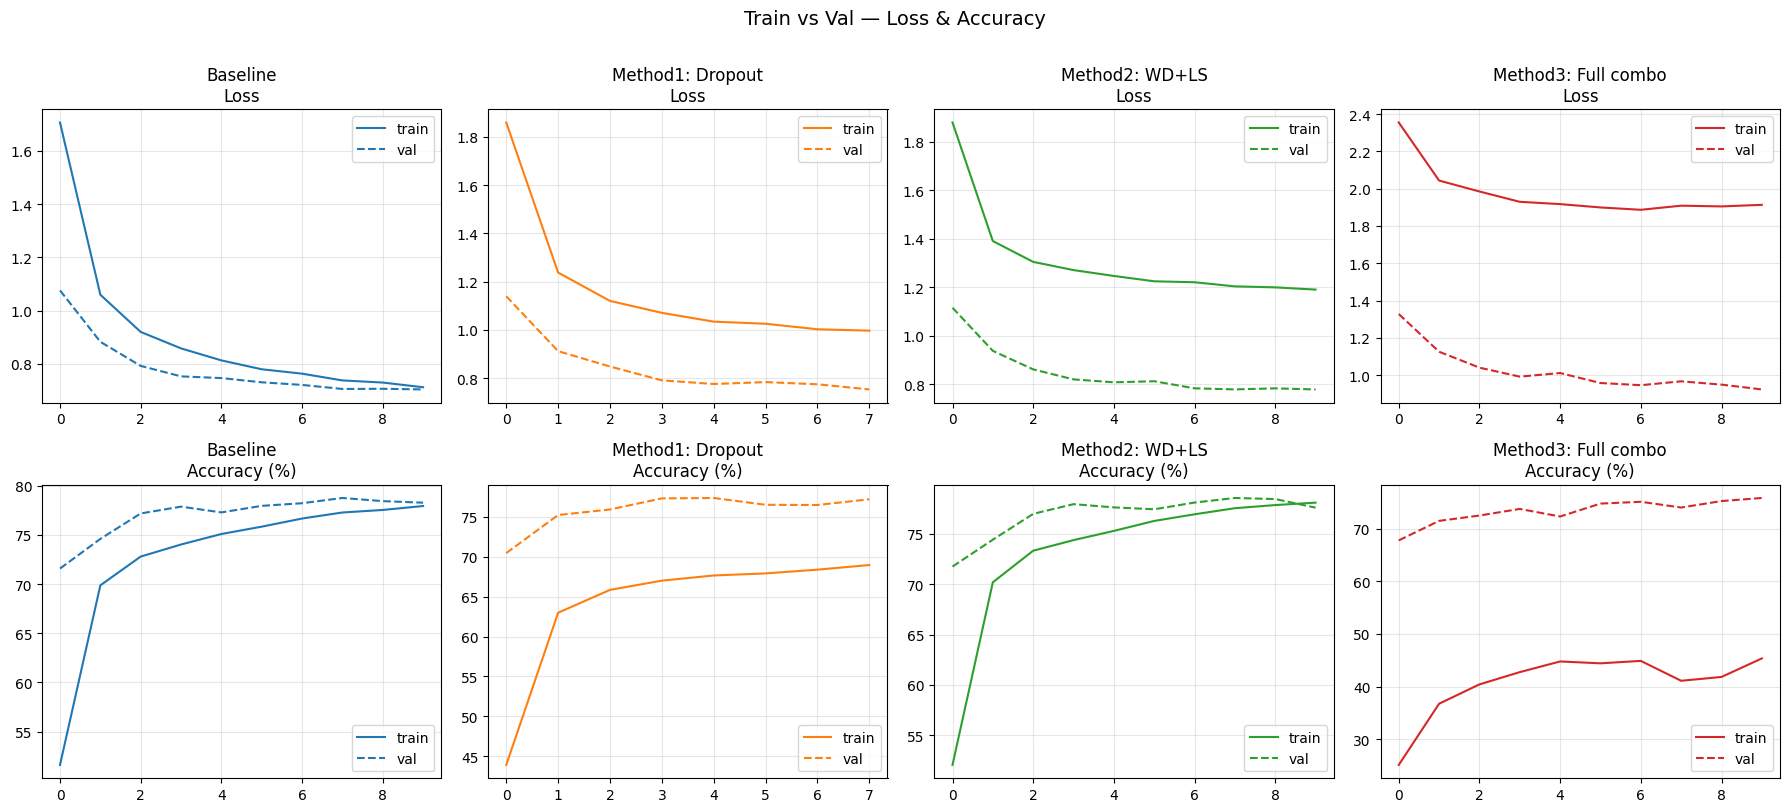

In [ ]:
# ---------- Визуализация 1: Train/Val loss curves ----------
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
configs = [
    ("Baseline",             history_base,  "C0"),
    ("Method1: Dropout",     history_drop,  "C1"),
    ("Method2: WD+LS",       history_wd_ls, "C2"),
    ("Method3: Full combo",  history_full,  "C3"),
]
for col, (label, hist, color) in enumerate(configs):
    axes[0, col].plot(hist["train_loss"], label="train", color=color)
    axes[0, col].plot(hist["val_loss"],   label="val",   color=color, linestyle="--")
    axes[0, col].set_title(f"{label}\nLoss")
    axes[0, col].legend(); axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(np.array(hist["train_acc"])*100, label="train", color=color)
    axes[1, col].plot(np.array(hist["val_acc"])*100,   label="val",   color=color, linestyle="--")
    axes[1, col].set_title(f"{label}\nAccuracy (%)")
    axes[1, col].legend(); axes[1, col].grid(alpha=0.3)

plt.suptitle("Train vs Val - Loss & Accuracy", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("curves_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

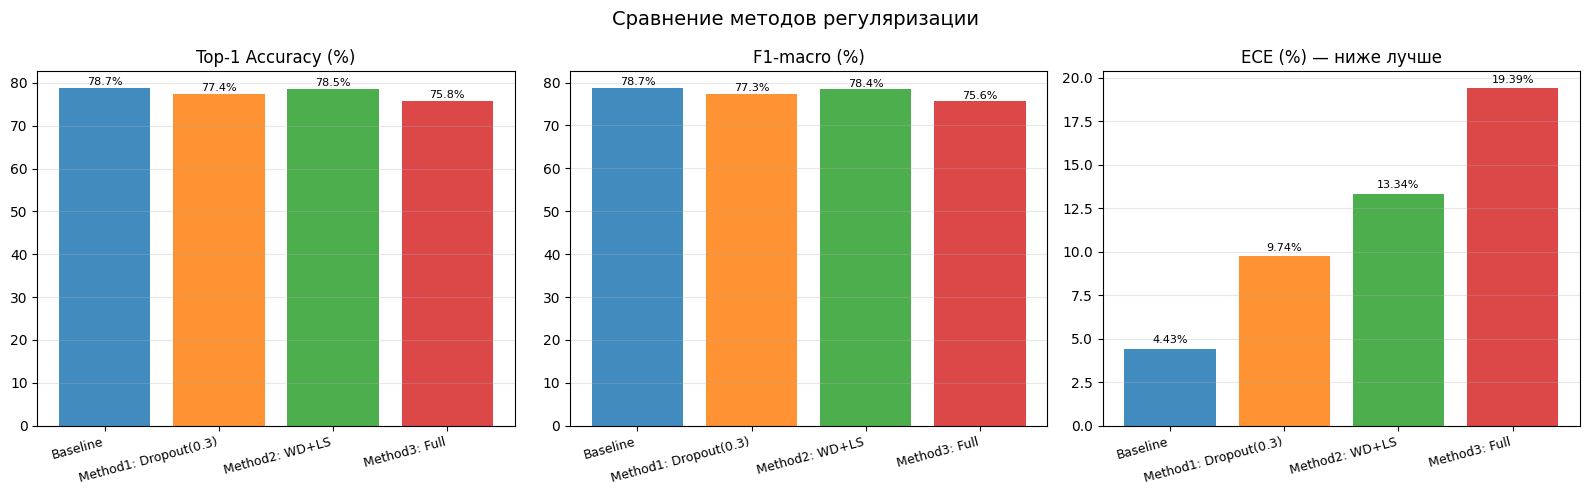

In [ ]:
# ---------- Визуализация 2: Bar-chart метрик ----------
labels = list(results.keys())
accs = [v[0]*100 for v in results.values()]
f1s  = [v[1]*100 for v in results.values()]
eces = [v[2]*100 for v in results.values()]

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vals, title, fmt in zip(
    axes,
    [accs, f1s, eces],
    ["Top-1 Accuracy (%)", "F1-macro (%)", "ECE (%) - ниже лучше"],
    ["%.1f%%", "%.1f%%", "%.2f%%"],
):
    bars = ax.bar(x, vals, color=["C0","C1","C2","C3"], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                fmt % v, ha="center", va="bottom", fontsize=8)

plt.suptitle("Сравнение методов регуляризации", fontsize=14)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

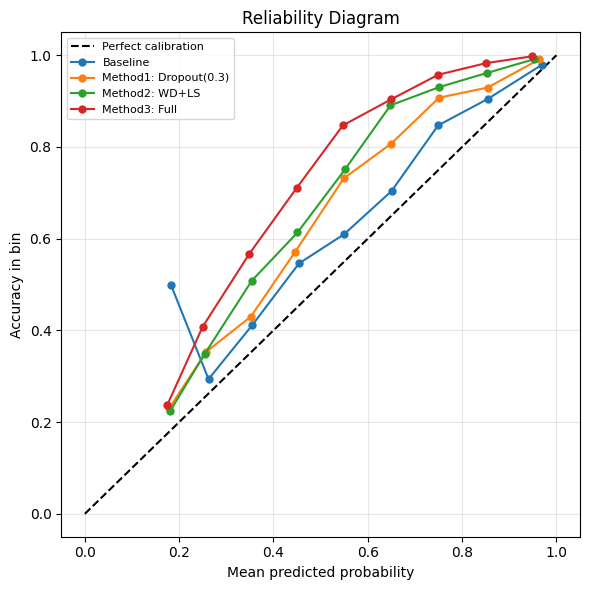

In [ ]:
# ---------- Визуализация 3: Reliability Diagram ----------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
for (name, _, _), (y, prob), color in zip(
    results.values(),
    [(y_base, prob_base), (y_drop, prob_drop), (y_wd, prob_wd), (y_full, prob_full)],
    ["C0", "C1", "C2", "C3"],
):
    pass

names_rd = list(results.keys())
data_rd  = [(y_base, prob_base), (y_drop, prob_drop), (y_wd, prob_wd), (y_full, prob_full)]
colors_rd = ["C0","C1","C2","C3"]

for name, (y_, prob_), col in zip(names_rd, data_rd, colors_rd):
    xs_r, ys_r = reliability_points(y_, prob_)
    ax.plot(xs_r, ys_r, "o-", label=name, color=col, markersize=5)

ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Accuracy in bin")
ax.set_title("Reliability Diagram")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reliability_diagram.png", dpi=120, bbox_inches="tight")
plt.show()

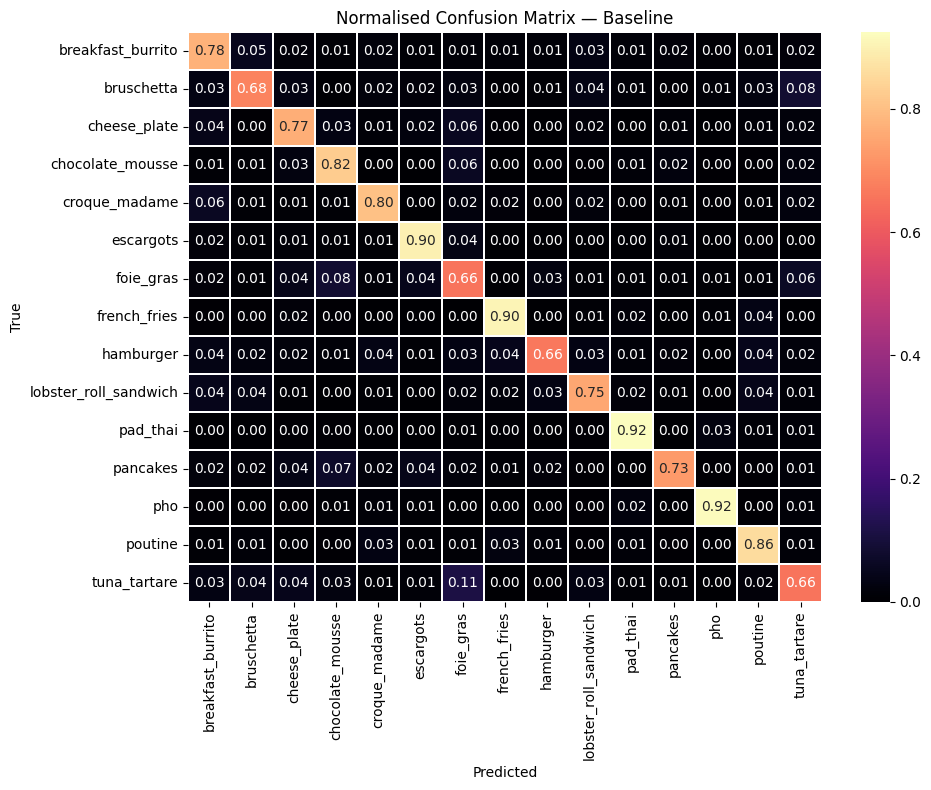

In [ ]:
# ---------- Визуализация 4: Confusion Matrix (Best model) ----------
best_name = max(results, key=lambda k: results[k][1])   # по F1
best_y, best_prob = data_rd[names_rd.index(best_name)]
best_p = best_prob.argmax(axis=1)

cm     = confusion_matrix(best_y, best_p, labels=list(range(NUM_CLASSES)))
cm_n   = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="magma",
            xticklabels=class_names_small, yticklabels=class_names_small, ax=ax,
            linewidths=0.3, linecolor="white")
ax.set_title(f"Normalised Confusion Matrix - {best_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_best.png", dpi=120, bbox_inches="tight")
plt.show()

In [48]:
# ---------- Сводная таблица: разрыв train-val ----------
print("\n--- Разрыв train_acc - val_acc (последняя эпоха) ---")
for label, hist, _ in configs:
    gap = (hist["train_acc"][-1] - hist["val_acc"][-1]) * 100
    print(f"  {label:<28}  gap = {gap:+.1f}%")

print("\n=== ИТОГ ===")
print(f"  Лучший по F1-macro : {best_name}")
best_acc, best_f1, best_ece = results[best_name]
base_acc, base_f1, base_ece = results["Baseline"]
print(f"  d Acc  = {(best_acc - base_acc)*100:+.2f}%")
print(f"  d F1   = {(best_f1  - base_f1 )*100:+.2f}%")
print(f"  d ECE  = {(best_ece - base_ece)*100:+.3f}%  (отрицательное - лучше)")


--- Разрыв train_acc - val_acc (последняя эпоха) ---
  Baseline                      gap = -0.3%
  Method1: Dropout              gap = -8.2%
  Method2: WD+LS                gap = +0.5%
  Method3: Full combo           gap = -30.5%

=== ИТОГ ===
  Лучший по F1-macro : Baseline
  d Acc  = +0.00%
  d F1   = +0.00%
  d ECE  = +0.000%  (отрицательное - лучше)


Не получилось сделать лучше чем Baseline, пытался по всякому. Пытался найти объяснение, вот единственное что нашел:

gap у baseline равен -0.3% (val чуть лучше train). Это означает, что переобучения нет вообще. Если нет переобучения - регуляризировать не поможет